In [124]:
# load the necessary functions
# for (fnm in list.files("/home/jovyan/shared_materials/rwwa", full.names = T)) source(fnm)

# import R libraries from WWA
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.vectors import ListVector
from c3s_event_attribution_tools import Utils

ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

# print(ro.r('.libPaths()'))

R callback write-console: Using GitHub PAT from the git credential store.
  
R callback write-console: Skipping install of 'rwwa' from a github remote, the SHA1 (236d9a6b) has not changed since last install.
  Use `force = TRUE` to force installation
  


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [125]:
your_save_directory = Utils.get_save_directory(dir="../data")

# Synthesise results from observations and climate models

In [126]:
%%R -i your_save_directory

observations_path <- file.path(your_save_directory, "res-obs_era5.csv")

# load the observational results
df_obs <- read.csv(observations_path, row.names = "X")

In [127]:
%%R

models_path = file.path(your_save_directory, "res-models-Future-2.6.csv")

# load the climate model results
df_models <- read.csv(models_path, row.names = "X")

In [ ]:
%%R
# Should we make a little R library as well? Is this easy to include in the py library?

filter_models <- function(df, include = c("true", "false", "both")) {
    include <- match.arg(include)

    if (include == "true") {
        df <- df[df$Include == TRUE, ]
    } else if (include == "false") {
    df <- df[df$Include == FALSE, ]
    } 
    # "both" returns df unchanged

    df
}


In [ ]:
%%R
# Maybe change the name for this column

df_models$Include <- as.logical(df_models$Include)
# Only models with Include == TRUE
df_models <- filter_models(df_models, "true")

In [130]:
%%R
# if looking at temperature data / 'shift' fit, use "abs";
# if looking at precipitation / 'fixeddisp', use "rel";
# use PR for probability ratio
synthesis_type <- "abs"

In [131]:
%%R
# change in intensity from past-present

synth_dI_attr <- synthesis(obs_in = df_obs[,grepl(paste0("dI.", synthesis_type), colnames(df_obs))], 
                           models_in = df_models[,grepl(paste0("attr_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from past-present (if there are any infinite values in the PRs, replace them with estimated values)
synth_PR_attr <- synthesis(obs_in = infer_infinite(df_obs[,grepl("PR", colnames(df_obs))]), 
                           models_in = infer_infinite(df_models[,grepl("attr_PR", colnames(df_models))]), 
                           synth_type = "PR")

# if you see error/warning messages below, you probably have infinite best estimates in your observations - ask us how to handle these

In [132]:
%%R
# change in intensity from present-future
synth_dI_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl(paste0("proj_dI.", synthesis_type), colnames(df_models))], 
                           synth_type = synthesis_type)

# change in likelihood from present-future
synth_PR_proj <- synthesis(obs_in = NA, 
                           models_in = df_models[,grepl("proj_PR", colnames(df_models))], 
                           synth_type = "PR")

In [133]:
%%R
# save all the synthesised results
write.csv(synth_dI_attr$df, file.path(your_save_directory, "synth_dI_attr.csv"))
write.csv(synth_PR_attr$df, file.path(your_save_directory, ".synth_PR_attr.csv"))
write.csv(synth_dI_proj$df, file.path(your_save_directory, "synth_dI_proj.csv"))
write.csv(synth_PR_proj$df, file.path(your_save_directory, "synth_PR_proj.csv"))

## Synthesis figures

In [134]:
%%R
prep_rc = c(1, 2)
prep_h = 5
prep_w = 5
prep_res = 200
prep_pch = 20
prep_oma = c(0, 20, 0, 0)
prep_mar = c(3, .5, 2, .5)

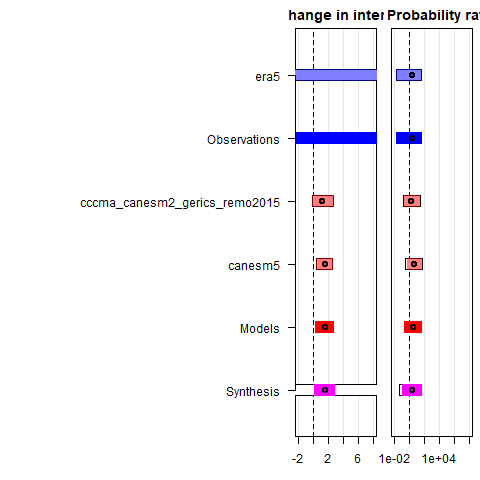

In [135]:
%%R
# put two figures next to each other
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # increase second number until model names fit in margin
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_attr, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
plot_synthesis(synth_PR_attr, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))

In [136]:
%%R
prep_rc = c(1, 2)
prep_h = 3
prep_w = 5
prep_res = 200
prep_pch = 20
prep_oma = c(0, 20, 0, 0)
prep_mar = c(3, .5, 2, .5)

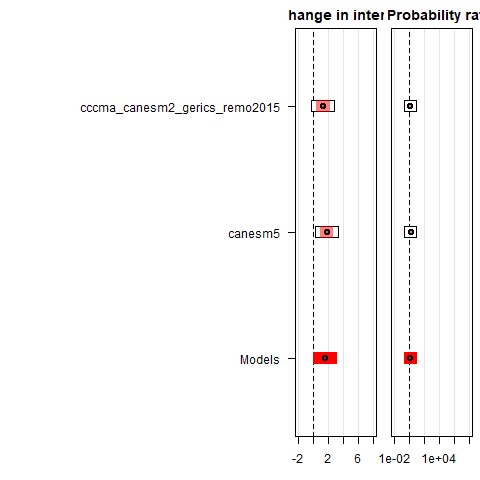

In [137]:
%%R
prep_window(prep_rc,
            h = prep_h,         # height of the figure (ins)
            w = prep_w,         # width of each panel (ins)
            res = prep_res,
            pch = prep_pch,
            oma = prep_oma,     # increase second number until model names fit in margin
            mar = prep_mar)     # shouldn't need to be changed

# set the x-axis (xlim) so that both the past & future changes use the same scaling
plot_synthesis(synth_dI_proj, lwd=12, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
plot_synthesis(synth_PR_proj, lwd=12, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))

## Produce figures of the synthesis

In [138]:
%%R

attr_export_path <- file.path(your_save_directory, "synth-fig_attr.png")

png(attr_export_path, height = 360, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_attr, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_attr, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

png 
  2 


In [139]:
%%R

proj_export_path <- file.path(your_save_directory, "synth-fig_proj.png")

png(proj_export_path, height = 240, width = 480*1.5); par(mfrow = c(1,2), oma = c(0,20,0,0), mar = c(3,0.5,2,0.5)); {
    # set the x-axis (xlim) so that both the past & future changes use the same scaling
    plot_synthesis(synth_dI_proj, add_space = F, main = "(a) Change in intensity", xlim = c(-2,8))
    plot_synthesis(synth_PR_proj, add_space = F, hide_labels = T, main = "(b) Probability ratio", xlim = c(1e-2, 1e8))
}; dev.off()

png 
  2 
